# Step 00 — Data provenance and objective reproducibility audit

This notebook validates the implemented **step 00** pipeline against the local repository data.

Scope of this step:

- discover the historical SQLite studies and trace sources;
- recompute historical best-trial objectives against candidate trace sources;
- keep the Control provenance ambiguity explicit;
- inventory the 37 ATF files by **region** (`DH`, `VH`) and **condition**.

This step is **provenance-only**. It does not claim biological degeneracy.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path(os.environ.get('ASTROMODEL_PROJECT_ROOT', Path.cwd())).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.provenance import run_step00_provenance

print(f'PROJECT_ROOT={PROJECT_ROOT}')
print(f'initial_fit_dir={(PROJECT_ROOT / "data" / "1_Initial_xp_fit")}')
print(f'atf_dir={(PROJECT_ROOT / "data" / "2_K+ Pumps Data")}')

PROJECT_ROOT=/mnt/data/astromodel_impl
initial_fit_dir=/mnt/data/astromodel_impl/data/1_Initial_xp_fit
atf_dir=/mnt/data/astromodel_impl/data/2_K+ Pumps Data


In [2]:
results = run_step00_provenance(PROJECT_ROOT)
db_summary = results['db_study_summary']
trace_summary = results['trace_source_summary']
provenance = results['control_trace_verification']
atf_inventory = results['atf_region_condition_inventory']
atf_counts = results['atf_region_condition_counts']

print('written outputs:', sorted((PROJECT_ROOT / 'outputs' / 'provenance').glob('*.csv')))
print('db rows:', len(db_summary), 'trace rows:', len(trace_summary), 'ATF rows:', len(atf_inventory))

written outputs: [PosixPath('/mnt/data/astromodel_impl/outputs/provenance/atf_region_condition_counts.csv'), PosixPath('/mnt/data/astromodel_impl/outputs/provenance/atf_region_condition_inventory.csv'), PosixPath('/mnt/data/astromodel_impl/outputs/provenance/control_trace_verification.csv'), PosixPath('/mnt/data/astromodel_impl/outputs/provenance/db_study_summary.csv'), PosixPath('/mnt/data/astromodel_impl/outputs/provenance/trace_source_summary.csv')]
db rows: 18 trace rows: 4 ATF rows: 37


## Historical DB study inventory

,db_name,study_name,condition,current_na,target_mean_mode,objective_loss_type,n_target_points,n_trials,n_complete,best_trial_number,best_objective
0,BARIUM_50nA.db,BARIUM_50nA_centered_L2_20000t_20240930_133313,BARIUM,50,centered,L2,20000,11907,11906,0,3450.286230
1,BARIUM_75nA.db,BARIUM_75nA_centered_L2_20000t_20240930_133312,BARIUM,75,centered,L2,20000,11925,11924,0,5848.293742
2,BARIUM_100nA.db,BARIUM_100nA_centered_L2_20000t_20240930_133313,BARIUM,100,centered,L2,20000,11903,11902,0,7963.653221
3,BARIUM_125nA.db,BARIUM_125nA_centered_L2_20000t_20240930_133313,BARIUM,125,centered,L2,20000,11914,11913,0,13492.704819
4,BARIUM_150nA.db,BARIUM_150nA_centered_L2_20000t_20240930_133313,BARIUM,150,centered,L2,20000,11924,11923,4311,23509.572968
5,BARIUM_175nA.db,BARIUM_175nA_centered_L2_20000t_20240930_133313,BARIUM,175,centered,L2,20000,11942,11941,0,28903.238239
6,CONTROL_50nA.db,CONTROL_50nA_centered_L2_2500t,CONTROL,50,centered,L2,2500,2500,2500,2067,21.502226
7,CONTROL_75nA.db,CONTROL_75nA_centered_L2_2500t,CONTROL,75,centered,L2,2500,2500,2500,2425,30.054498
8,CONTROL_100nA.db,CONTROL_100nA_centered_L2_2500t,CONTROL,100,centered,L2,2500,2500,2500,1943,38.365141
9,CONTROL_125nA.db,CONTROL_125nA_centered_L2_2500t,CONTROL,125,centered,L2,2500,2500,2500,1929,102.645495


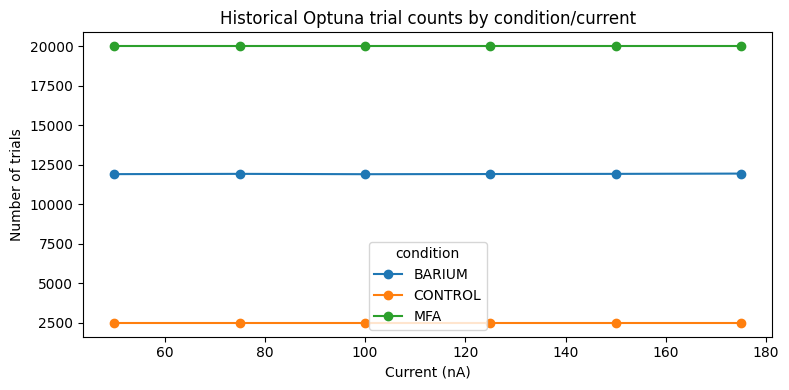

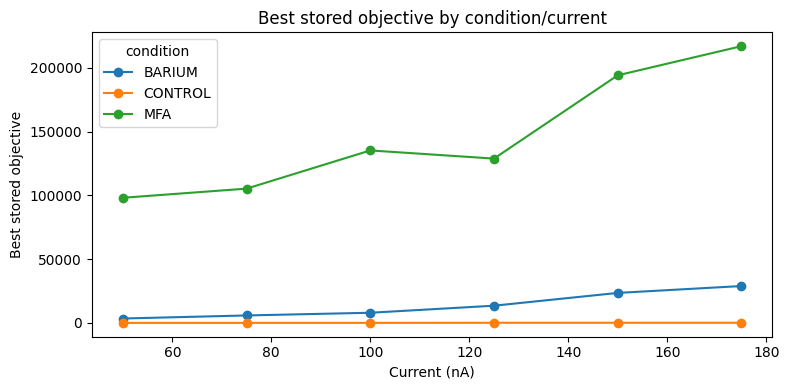

In [3]:
display(db_summary)

pivot_trials = db_summary.pivot(index='current_na', columns='condition', values='n_trials').sort_index()
ax = pivot_trials.plot(marker='o', figsize=(8, 4), title='Historical Optuna trial counts by condition/current')
ax.set_xlabel('Current (nA)')
ax.set_ylabel('Number of trials')
plt.tight_layout()
plt.show()

pivot_best = db_summary.pivot(index='current_na', columns='condition', values='best_objective').sort_index()
ax = pivot_best.plot(marker='o', figsize=(8, 4), title='Best stored objective by condition/current')
ax.set_xlabel('Current (nA)')
ax.set_ylabel('Best stored objective')
plt.tight_layout()
plt.show()

## Trace source inventory

In [4]:
display(trace_summary)

trace_dt = trace_summary[['trace_source', 'condition', 'rows', 'dt_ms', 'uses_header']].copy()
display(trace_dt)

,trace_source,condition,rows,n_columns,time_start_ms,time_end_ms,dt_ms,uses_header,file_size_bytes
0,BARIUM_TRACES.csv,BARIUM,364969,7,0.0,72993.6,0.2,False,24883254
1,CONTROL_TRACES.csv,CONTROL,50031,7,0.0,50030.0,1.0,False,3100699
2,CONTROL_TRACES_old.csv,CONTROL,500,7,0.0,49900.0,100.0,True,40563
3,MFA_TRACES.csv,MFA,364969,7,0.0,72993.6,0.2,False,25187251


,trace_source,condition,rows,dt_ms,uses_header
0,BARIUM_TRACES.csv,BARIUM,364969,0.2,False
1,CONTROL_TRACES.csv,CONTROL,50031,1.0,False
2,CONTROL_TRACES_old.csv,CONTROL,500,100.0,True
3,MFA_TRACES.csv,MFA,364969,0.2,False


## Objective reproducibility and Control provenance

,db_name,study_name,condition,current_na,trace_source,target_mean_mode,objective_loss_type,n_target_points,best_trial_number,stored_objective,recomputed_objective,relative_objective_error,status,chosen_trace_source,chosen_relative_objective_error,chosen_status
0,BARIUM_50nA.db,BARIUM_50nA_centered_L2_20000t_20240930_133313,BARIUM,50,BARIUM_TRACES.csv,centered,L2,20000,0,3450.286230,3450.068017,0.000063,verified,BARIUM_TRACES.csv,0.000063,verified
1,BARIUM_75nA.db,BARIUM_75nA_centered_L2_20000t_20240930_133312,BARIUM,75,BARIUM_TRACES.csv,centered,L2,20000,0,5848.293742,5848.496261,0.000035,verified,BARIUM_TRACES.csv,0.000035,verified
2,BARIUM_100nA.db,BARIUM_100nA_centered_L2_20000t_20240930_133313,BARIUM,100,BARIUM_TRACES.csv,centered,L2,20000,0,7963.653221,7963.606994,0.000006,verified,BARIUM_TRACES.csv,0.000006,verified
3,BARIUM_125nA.db,BARIUM_125nA_centered_L2_20000t_20240930_133313,BARIUM,125,BARIUM_TRACES.csv,centered,L2,20000,0,13492.704819,13492.676885,0.000002,verified,BARIUM_TRACES.csv,0.000002,verified
4,BARIUM_150nA.db,BARIUM_150nA_centered_L2_20000t_20240930_133313,BARIUM,150,BARIUM_TRACES.csv,centered,L2,20000,4311,23509.572968,23509.789390,0.000009,verified,BARIUM_TRACES.csv,0.000009,verified
5,BARIUM_175nA.db,BARIUM_175nA_centered_L2_20000t_20240930_133313,BARIUM,175,BARIUM_TRACES.csv,centered,L2,20000,0,28903.238239,28903.329357,0.000003,verified,BARIUM_TRACES.csv,0.000003,verified
6,CONTROL_50nA.db,CONTROL_50nA_centered_L2_2500t,CONTROL,50,CONTROL_TRACES_old.csv,centered,L2,2500,2067,21.502226,90.996788,3.231971,unresolved,CONTROL_TRACES_old.csv,3.231971,unresolved
7,CONTROL_50nA.db,CONTROL_50nA_centered_L2_2500t,CONTROL,50,CONTROL_TRACES.csv,centered,L2,2500,2067,21.502226,4897.230255,226.754575,unresolved,CONTROL_TRACES_old.csv,3.231971,unresolved
8,CONTROL_75nA.db,CONTROL_75nA_centered_L2_2500t,CONTROL,75,CONTROL_TRACES_old.csv,centered,L2,2500,2425,30.054498,160.715523,4.347470,unresolved,CONTROL_TRACES_old.csv,4.347470,unresolved
9,CONTROL_75nA.db,CONTROL_75nA_centered_L2_2500t,CONTROL,75,CONTROL_TRACES.csv,centered,L2,2500,2425,30.054498,7330.351969,242.901992,unresolved,CONTROL_TRACES_old.csv,4.347470,unresolved


,db_name,condition,current_na,chosen_trace_source,chosen_relative_objective_error,chosen_status
0,BARIUM_50nA.db,BARIUM,50,BARIUM_TRACES.csv,0.000063,verified
1,BARIUM_75nA.db,BARIUM,75,BARIUM_TRACES.csv,0.000035,verified
2,BARIUM_100nA.db,BARIUM,100,BARIUM_TRACES.csv,0.000006,verified
3,BARIUM_125nA.db,BARIUM,125,BARIUM_TRACES.csv,0.000002,verified
4,BARIUM_150nA.db,BARIUM,150,BARIUM_TRACES.csv,0.000009,verified
5,BARIUM_175nA.db,BARIUM,175,BARIUM_TRACES.csv,0.000003,verified
6,CONTROL_50nA.db,CONTROL,50,CONTROL_TRACES_old.csv,3.231971,unresolved
8,CONTROL_75nA.db,CONTROL,75,CONTROL_TRACES_old.csv,4.347470,unresolved
10,CONTROL_100nA.db,CONTROL,100,CONTROL_TRACES_old.csv,5.902699,unresolved
12,CONTROL_125nA.db,CONTROL,125,CONTROL_TRACES_old.csv,4.156479,unresolved


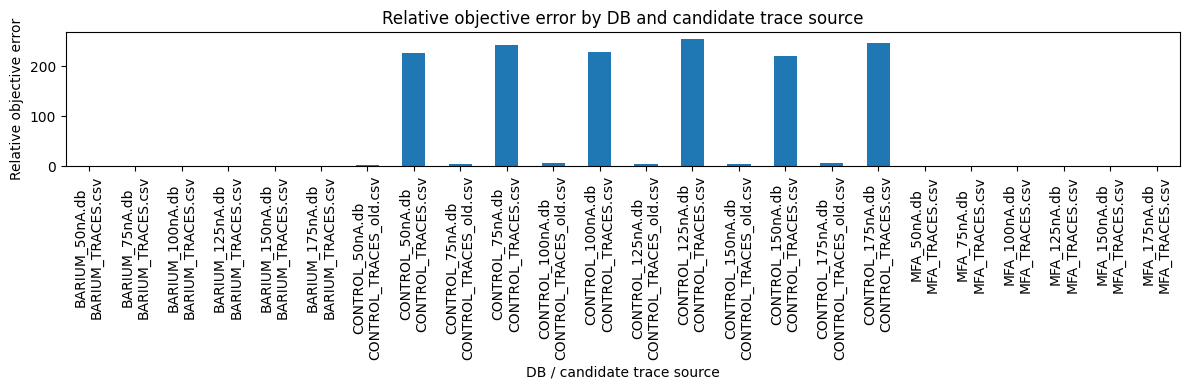

In [5]:
display(provenance)

chosen = provenance.drop_duplicates('db_name')[['db_name', 'condition', 'current_na', 'chosen_trace_source', 'chosen_relative_objective_error', 'chosen_status']].sort_values(['condition', 'current_na'])
display(chosen)

plot_df = provenance.copy()
plot_df['label'] = plot_df['db_name'] + '\n' + plot_df['trace_source']
ax = plot_df.plot(kind='bar', x='label', y='relative_objective_error', figsize=(12, 4), legend=False, title='Relative objective error by DB and candidate trace source')
ax.set_xlabel('DB / candidate trace source')
ax.set_ylabel('Relative objective error')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Region-aware ATF inventory

,file_id,region,condition,source_path
0,1_DH_1,DH,CONTROL,/mnt/data/astromodel_impl/data/2_K+ Pumps Data...
1,1_DH_2,DH,CONTROL,/mnt/data/astromodel_impl/data/2_K+ Pumps Data...
2,2_DH_1,DH,CONTROL,/mnt/data/astromodel_impl/data/2_K+ Pumps Data...
3,3_DH_1,DH,CONTROL,/mnt/data/astromodel_impl/data/2_K+ Pumps Data...
4,3_DH_2,DH,CONTROL,/mnt/data/astromodel_impl/data/2_K+ Pumps Data...
5,DH_old,DH,CONTROL,/mnt/data/astromodel_impl/data/2_K+ Pumps Data...
6,DH_old_2,DH,CONTROL,/mnt/data/astromodel_impl/data/2_K+ Pumps Data...
7,1_VH_1,VH,CONTROL,/mnt/data/astromodel_impl/data/2_K+ Pumps Data...
8,1_VH_2,VH,CONTROL,/mnt/data/astromodel_impl/data/2_K+ Pumps Data...
9,2_VH_1,VH,CONTROL,/mnt/data/astromodel_impl/data/2_K+ Pumps Data...


,region,condition,n_cells,expected_n_cells,matches_expected,small_stratum
0,DH,CONTROL,7,7,True,False
1,DH,MFA,6,6,True,False
2,DH,MFA_BA,6,6,True,False
3,VH,CONTROL,4,4,True,True
4,VH,MFA,7,7,True,False
5,VH,MFA_BA,7,7,True,False


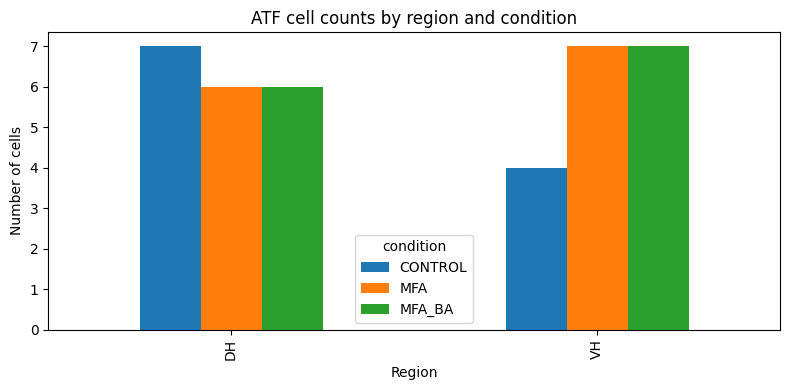

In [6]:
display(atf_inventory.head(10))
display(atf_counts)

counts_pivot = atf_counts.pivot(index='region', columns='condition', values='n_cells').loc[['DH', 'VH']]
ax = counts_pivot.plot(kind='bar', figsize=(8, 4), title='ATF cell counts by region and condition')
ax.set_xlabel('Region')
ax.set_ylabel('Number of cells')
plt.tight_layout()
plt.show()

## Interpretation

This notebook shows that the historical studies are locally auditable and that the 37 ATF files satisfy the updated region-aware design contract. It also shows that the Control historical provenance remains unresolved under the documented objective-recomputation contract, so Control historical fits must not be treated as fully validated reviewer-facing inputs.